<a href="https://colab.research.google.com/github/daistic/Final-Project---Expert-System/blob/main/Final_Project_Expert_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Pemrosesan Data

### Download Dataset

In [ ]:
# !pip install kagglehub

In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download(
    "aldiarisandi/dataset-penyakit-tanaman"
)

print("Path dataset:", path)

print(os.listdir(path))

100%|██████████| 2.61k/2.61k [00:00<00:00, 3.09MB/s]

Extracting files...
Path dataset: /root/.cache/kagglehub/datasets/aldiarisandi/dataset-penyakit-tanaman/versions/1
['dataset_penyakit_tanaman.csv']


In [ ]:
import pandas as pd
import os

# Membaca dataset
file_csv = os.path.join(
    path,
    "dataset_penyakit_tanaman.csv"
)

df = pd.read_csv(file_csv)

print("Jumlah Data:", len(df))

display(df.head())

Jumlah Data: 300


,ID,Nama_Tanaman,Warna_Daun,Bercak_Daun,Daun_Layu,Batang_Busuk,Pertumbuhan_Terhambat,Penyakit
0,1,Stroberi,Kuning,Tidak,Ya,Ya,Ya,Busuk Lunak
1,2,Mangga,Hijau,Ya,Ya,Tidak,Tidak,Karat Daun
2,3,Kentang,Hijau,Ya,Tidak,Tidak,Ya,Busuk Hitam
3,4,Mangga,Kuning,Tidak,Tidak,Tidak,Tidak,Hawar Daun Bakteri
4,5,Melon,Kuning,Tidak,Ya,Ya,Tidak,Antraknosa


### Data Cleaning

In [ ]:
# Menghapus missing value
df = df.dropna()

# Menghapus data duplikat
df = df.drop_duplicates()

print("Jumlah Data Setelah Cleaning:")
print(len(df))

display(df.head())

Jumlah Data Setelah Cleaning:
300


,ID,Nama_Tanaman,Warna_Daun,Bercak_Daun,Daun_Layu,Batang_Busuk,Pertumbuhan_Terhambat,Penyakit
0,1,Stroberi,Kuning,Tidak,Ya,Ya,Ya,Busuk Lunak
1,2,Mangga,Hijau,Ya,Ya,Tidak,Tidak,Karat Daun
2,3,Kentang,Hijau,Ya,Tidak,Tidak,Ya,Busuk Hitam
3,4,Mangga,Kuning,Tidak,Tidak,Tidak,Tidak,Hawar Daun Bakteri
4,5,Melon,Kuning,Tidak,Ya,Ya,Tidak,Antraknosa


### Menambahkan Solusi Penyakit

In [ ]:
solusi_penyakit = {

    "Antraknosa":
    "Pemulihan tanaman dilakukan dengan pemberian pupuk mikro melalui daun untuk menormalisasi kinerja enzim-enzim dan merangsang pembentukan hormon-hormon alamiah bagi pembentukan sel-sel baru secara lebih cepat.",

    "Bercak Daun":
    "Membuang umbi atau buah yang terserang, menghindari penggunaan pupuk nitrogen yang berlebihan, melakukan tindakan pencegahan jika sudah terkena gejala serangan dengan fungisida sistemik atau kontak.",

    "Bercak Daun Cercospora":
    "Perawatan benih dengan air panas pada suhu 52 °C selama 30 menit untuk mengurangi keberadaan jamur pada biji. Perawatan lain yang dapat dilakukan adalah penyemprotan daun dengan produk-produk yang mengandung tembaga hidroksida, klorotalonil, atau mancozeb.",

    "Busuk Lunak":
    "Daun yang terinfeksi harus dibuang, serta batang bekas potongan diolesi dengan cairan klorin. Berikan agen hayati untuk memanfaatkan bakteri yang ada pada agen hayati seperti Pseudomonas fluorescens & Trichoderma sp. Lakukan penyemprotan fungisida dengan bahan aktif tembaga, streptomicyn sulfat, dan asam oksolinik.",

    "Busuk Akar Phytophtora":
    "Memperbaiki drainase untuk mencegah genangan, pangkas bagian tanaman yang layu, dan aplikasikan fungisida seperti Metalaksil atau Fosetil-Aluminium pada pangkal batang. Tanaman yang sudah parah sebaiknya dicabut dan dibakar agar spora tidak menyebar.",

    "Karat Daun":
    "Penggunaan fungisida berbahan aktif seperti mancozeb, propiconazole, atau chlorothalonil dapat membantu mengendalikan penyakit. Membersihkan sisa-sisa tanaman yang terinfeksi setelah panen dapat mencegah penyebaran spora jamur ke musim tanam berikutnya.",

    "Layu Fusarium":
    "Pengelolaan tanah yang baik, rotasi tanaman, penggunaan benih sehat dan pengendalian dengan fungisida dengan bahan aktif mancozeb, difenokonazol dan benomyl serta agen pengendali hayati seperti Trichoderma sp.",

    "Embun Tepung":
    "Menggunakan fungisida alami seperti larutan air susu, soda kue, minyak nimba, belerang, bawang putih, cuka, serta teh kompos.",

    "Busuk Buah Botrytis":
    "Keluarkan bagian yang terinfeksi secermat mungkin tanpa membiarkannya bersentuhan dengan tanaman sehat. Pengendalian hayati dengan bakteri seperti Bacillus subtilis dan produk tumbuhan alami seperti minyak thyme. Memberi jarak tanaman untuk memperlancar sirkulasi udara yang baik dan menyediakan irigasi yang cukup untuk menghindari penyiraman yang berlebihan dapat membantu mencegah penyakit muncul.",

    "Layu Bakteri":
    "Gunakan agen hayati seperti Bacillus siamensis, Paenibacillus polymyxa, Bacillus amyloliquefaciens, dan Bacillus subtilis.",

    "Jamur Upas":
    "Setelah melakukan pemantauan dan menemukan tanaman yang sudah terinfeksi jamur upas, segera lakukan pemangkasan pada bagian yang terkena. Selain itu, gunakan fungisida yang mengandung bahan aktif seperti Metalaxyl atau Fosetil-Aluminium.",

    "Busuk Hitam":
    "Daun yang terinfeksi harus dibuang, serta batang bekas potongan diolesi dengan cairan klorin. Berikan agen hayati untuk memanfaatkan bakteri yang ada pada agen hayati seperti Pseudomonas fluorescens & Trichoderma sp. Lakukan penyemprotan fungisida dengan bahan aktif tembaga, streptomicyn sulfat, dan asam oksolinik.",

    "Hawar Daun Bakteri":
    "Memanfaatkan agensia hayati seperti Corynebacterium. Upaya lain untuk mengatasi hawar daun yakni dengan memberikan bakterisida seperti Kuproxat 345 SC. Bakterisida sekaligus fungisida ini mengandung bahan aktif tembaga oksi-sulfat dengan formulasi cair berteknologi tri base blue.",

    "Busuk Akar":
    "Buang sebanyak mungkin tanah yang terinfeksi dengan mengocoknya dengan lembut dari akarnya dan kemudian menanam kembali tanaman di tanah pot yang bersih dan baru."
}

df["Solusi"] = df["Penyakit"].map(solusi_penyakit)

print("Dataset setelah penambahan solusi:")
display(df.head())

Dataset setelah penambahan solusi:


,ID,Nama_Tanaman,Warna_Daun,Bercak_Daun,Daun_Layu,Batang_Busuk,Pertumbuhan_Terhambat,Penyakit,Solusi
0,1,Stroberi,Kuning,Tidak,Ya,Ya,Ya,Busuk Lunak,"Daun yang terinfeksi harus dibuang, serta bata..."
1,2,Mangga,Hijau,Ya,Ya,Tidak,Tidak,Karat Daun,Penggunaan fungisida berbahan aktif seperti ma...
2,3,Kentang,Hijau,Ya,Tidak,Tidak,Ya,Busuk Hitam,"Daun yang terinfeksi harus dibuang, serta bata..."
3,4,Mangga,Kuning,Tidak,Tidak,Tidak,Tidak,Hawar Daun Bakteri,Memanfaatkan agensia hayati seperti Corynebact...
4,5,Melon,Kuning,Tidak,Ya,Ya,Tidak,Antraknosa,Pemulihan tanaman dilakukan dengan pemberian p...


### Membentuk Casebase

In [ ]:
case_base = df.copy()

print("Jumlah Case :", len(case_base))

display(case_base.head())

Jumlah Case : 300


,ID,Nama_Tanaman,Warna_Daun,Bercak_Daun,Daun_Layu,Batang_Busuk,Pertumbuhan_Terhambat,Penyakit,Solusi
0,1,Stroberi,Kuning,Tidak,Ya,Ya,Ya,Busuk Lunak,"Daun yang terinfeksi harus dibuang, serta bata..."
1,2,Mangga,Hijau,Ya,Ya,Tidak,Tidak,Karat Daun,Penggunaan fungisida berbahan aktif seperti ma...
2,3,Kentang,Hijau,Ya,Tidak,Tidak,Ya,Busuk Hitam,"Daun yang terinfeksi harus dibuang, serta bata..."
3,4,Mangga,Kuning,Tidak,Tidak,Tidak,Tidak,Hawar Daun Bakteri,Memanfaatkan agensia hayati seperti Corynebact...
4,5,Melon,Kuning,Tidak,Ya,Ya,Tidak,Antraknosa,Pemulihan tanaman dilakukan dengan pemberian p...


### Menyimpan Knowledgebase

In [ ]:
case_base.to_csv(
    "knowledge_base.csv",
    index=False
)

print("Knowledge base berhasil dibuat.")

Knowledge base berhasil dibuat.


### Ringkasan Knowledge Base

In [ ]:
print("Jenis Tanaman:")
display(case_base["Nama_Tanaman"].value_counts())

print("Jenis Penyakit:")
display(case_base["Penyakit"].value_counts())

Jenis Tanaman:


,count
Nama_Tanaman,
Mangga,23
Melon,21
Kacang Tanah,21
Tebu,20
Wortel,20
Semangka,18
Jagung,18
Singkong,17
Bayam,17


Jenis Penyakit:


,count
Penyakit,
Karat Daun,33
Busuk Lunak,31
Antraknosa,28
Busuk Akar Phytophthora,27
Layu Fusarium,23
Embun Tepung,21
Busuk Hitam,19
Bercak Daun Cercospora,19
Bercak Daun,18


# 2. Penanganan Ketidakpastian

In [ ]:
def compute_cf(new_case, user_cf_values):
    global case_base

    expert_cf = 0.8
    disease_scores = {}
    gejala_keys = ['Warna_Daun', 'Bercak_Daun', 'Daun_Layu', 'Batang_Busuk', 'Pertumbuhan_Terhambat']

    # 1. CBR INDEXING: Filter berdasarkan nama tanaman
    relevant_cases = case_base[case_base['Nama_Tanaman'] == new_case['Nama_Tanaman']]
    if relevant_cases.empty:
        relevant_cases = case_base # Fallback jika tanaman tidak terdaftar

    best_cases_per_disease = {}

    # Perulangan memeriksa SELURUH baris kasus untuk mencari Nearest Neighbor
    for idx, row in relevant_cases.iterrows():
        disease = row['Penyakit']

        # Hitung CBR Similarity (Simple Matching Coefficient)
        match_count = 0
        for gejala in gejala_keys:
            if new_case.get(gejala) == row.get(gejala):
                match_count += 1

        similarity_score = match_count / len(gejala_keys)

        # Simpan atau update jika menemukan similarity lebih tinggi untuk penyakit ini
        if disease not in best_cases_per_disease or similarity_score > best_cases_per_disease[disease]['similarity']:
            best_cases_per_disease[disease] = {
                'case_row': row,
                'similarity': similarity_score
            }

    # 2. HITUNG CERTAINTY FACTOR & HARMONIC HYBRID SCORE
    for disease, data in best_cases_per_disease.items():
        best_row = data['case_row']
        similarity_score = data['similarity']

        cf_list = []
        for gejala, weight in user_cf_values.items():
            # CF dihitung jika user memberikan bobot positif dan gejala tersebut bernilai ya di database
            if weight > 0 and best_row.get(gejala) == 'Ya':
                cf_gejala = weight * expert_cf
                cf_list.append(cf_gejala)

        # Kombinasi CF Paralel
        combined_cf = 0
        if cf_list:
            combined_cf = cf_list[0]
            for i in range(1, len(cf_list)):
                combined_cf = combined_cf + (cf_list[i] * (1 - combined_cf))

        # IMPLEMENTASI HARMONIC MEAN HYBRID SCORE
        # Menghindari pembagian nol jika similarity dan cf bernilai 0
        if (similarity_score + combined_cf) > 0:
            hybrid_score = 2 * ((similarity_score * combined_cf) / (similarity_score + combined_cf))
        else:
            hybrid_score = 0.0

        disease_scores[disease] = {
            'score': hybrid_score,
            'cf': combined_cf,
            'similarity': similarity_score
        }

    if disease_scores:
        # Mengambil penyakit dengan Hybrid Score tertinggi
        diagnosis = max(disease_scores, key=lambda k: disease_scores[k]['score'])
        final_stats = disease_scores[diagnosis]
        best_case_reference = best_cases_per_disease[diagnosis]['case_row']
        return diagnosis, final_stats['cf'], final_stats['similarity'], best_case_reference
    else:
        return "Tidak Diketahui", 0.0, 0.0, None

# 3. Explanation Facility

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def explanation_facility(input_case, user_cf_values, diagnosis, sim_score, cf_score, final_hybrid, best_case):
    print("\n" + "="*60)
    print("                EXPLANATION FACILITY (FASILITAS PENJELASAN)        ")
    print("="*60)

    print("\n[1] ANALISIS PERLAKUAN INPUT GEJALA:")
    print("-" * 85)
    print(f"{'Nama Gejala':<25} | {'Bobot User':<12} | {'Status CBR':<12} | {'Dampak pada Perhitungan CF':<25}")
    print("-" * 85)

    for gejala, weight in user_cf_values.items():
        status_cbr = input_case[gejala]

        # Logika penjelasan dampak CF
        if weight > 0:
            dampak_cf = f"Ikut dihitung (Bobot: {weight})"
        elif weight == 0.0:
            dampak_cf = "Diabaikan (Netral)"
        else:
            dampak_cf = "Diabaikan (Fokus Validasi Absen Gejala)"

        nama_gejala_rapi = gejala.replace('_', ' ')
        print(f"{nama_gejala_rapi:<25} | {weight:<12} | {status_cbr:<12} | {dampak_cf:<25}")
    print("-" * 85)

    print("\n[2] FORMULA INFERENSI KEPUTUSAN:")
    print(f"- Nilai Kemiripan Kasus (CBR Similarity) : {round(sim_score * 100, 2)}%")
    print(f"- Akumulasi Faktor Kepastian (Total CF)  : {round(cf_score * 100, 2)}%")
    print(f"- Rumus Kombinasi (Harmonic Mean)        : 2 * (CBR * CF) / (CBR + CF)")
    print(f"  Hasil Akhir Keandalan (Hybrid Score): {round(final_hybrid * 100, 2)}% -> {diagnosis}")
    print("="*60)

    print("\n[3] JUSTIFIKASI CBR (KASUS REFERENSI TERDEKAT):")
    if best_case is not None:
        print(f"Sistem mengambil keputusan ini karena tanaman Anda memiliki kemiripan historis")
        print(f"dengan data kasus lama pada database, yaitu:")
        print(f" - Tanaman Referensi : {best_case['Nama_Tanaman']}")
        print(f" - Penyakit Terbukti : {best_case['Penyakit']}")
        print(f" - Warna Daun        : {best_case['Warna_Daun']}")
        print(f" - Daun Layu         : {best_case['Daun_Layu']}")
    else:
        print("Sistem tidak dapat menemukan kasus referensi yang relevan di database.")
    print("="*60)

    print("\n[Generating Alur Inferensi Graf...]")
    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()

    node_hasil = f"DIAGNOSIS:\n{diagnosis}\n({round(final_hybrid * 100, 1)}%)"
    G.add_node(node_hasil, node_type='hasil')

    for gejala, weight in user_cf_values.items():
        nama_g = gejala.replace('_', ' ')

        # Berikan label teks status pada node berdasarkan nilai inputnya
        if weight == 1.0:
            label_node = f"{nama_g}\n(Ya / +1.0)"
            node_color = 'lightgreen' # Gejala Valid Sangat Kuat
        elif weight == 0.5:
            label_node = f"{nama_g}\n(Mungkin / +0.5)"
            node_color = 'palegreen'  # Gejala Valid Sedang
        elif weight == 0.0:
            label_node = f"{nama_g}\n(Tak Tahu / 0.0)"
            node_color = 'lightgray'  # Netral
        elif weight == -0.5:
            label_node = f"{nama_g}\n(Mngk Tidak / -0.5)"
            node_color = 'wheat'      # Validasi Absen Ringan
        else: # -1.0
            label_node = f"{nama_g}\n(Tidak / -1.0)"
            node_color = 'sandybrown' # Validasi Absen Mutlak

        G.add_node(label_node, color=node_color, node_type='gejala')

        # Tentukan label garis relasi (edge) menuju hasil akhir
        if weight > 0:
            edge_label = "Memperkuat CF"
        else:
            edge_label = "Cocok Absen (CBR)"

        G.add_edge(label_node, node_hasil, label=edge_label)

    node_colors = [G.nodes[n].get('color', 'lightcoral') for n in G.nodes]
    node_sizes = [5000 if G.nodes[n].get('node_type') == 'hasil' else 3800 for n in G.nodes]

    pos = nx.shell_layout(G)

    # Gambar Node dan Garis Relasi
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes,
            font_size=8, font_weight='bold', arrows=True, edge_color='darkgray', width=1.5)

    # Tambah Label pada Garis Relasi
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='red')

    plt.title("Visualisasi Kontribusi Jenis Input terhadap Kesimpulan Sistem", fontsize=12, fontweight='bold')
    plt.margins(0.25)
    plt.show(block=False)
    plt.pause(0.5)

# 4. RETAIN

In [ ]:
import pandas as pd

def feedback_retain(input_case, diagnosis_final, df):
    if diagnosis_final in ["Tidak Diketahui", "Batal", ""]:
        print("\n[Info Retain] Kasus tidak valid, dilewati dari penyimpanan database.")
        return df

    new_case_dict = input_case.copy()
    new_case_dict['Penyakit'] = diagnosis_final

    if 'Solusi_Manual' in new_case_dict:
        # Jika ada input solusi manual dari user (utk penyakit 100% baru)
        new_case_dict['Solusi'] = new_case_dict.pop('Solusi_Manual')
    else:
        solusi_exist = df[df['Penyakit'] == diagnosis_final]['Solusi'].values
        new_case_dict['Solusi'] = solusi_exist[0] if len(solusi_exist) > 0 else "Solusi belum tersedia, silakan hubungi pakar."

    new_case_df = pd.DataFrame([new_case_dict])
    df_updated = pd.concat([df, new_case_df], ignore_index=True)

    df_updated.to_csv("knowledge_base.csv", index=False)
    print(f"\n[Success Retain] Pengalaman kasus baru berhasil dipelajari dan disimpan ke knowledge_base.csv!")
    print(f"Total database kasus saat ini: {len(df_updated)} data.")

    return df_updated

# 5. Main Program

=== SISTEM PAKAR HYBRID (CBR + CF) DIAGNOSIS PENYAKIT TANAMAN ===
Masukkan kondisi tanaman Anda saat ini:
- Apa nama tanaman? (misal: Mangga, Melon, dll): Mangga

- Apakah warna daun terlihat menguning?
1. Ya
2. Mungkin
3. Tidak Tahu
4. Mungkin Tidak
5. Tidak
Pilih (1-5): 3

- Apakah ada bercak pada daun?
1. Ya
2. Mungkin
3. Tidak Tahu
4. Mungkin Tidak
5. Tidak
Pilih (1-5): 2

- Apakah daun terlihat layu?
1. Ya
2. Mungkin
3. Tidak Tahu
4. Mungkin Tidak
5. Tidak
Pilih (1-5): 5

- Apakah batang membusuk?
1. Ya
2. Mungkin
3. Tidak Tahu
4. Mungkin Tidak
5. Tidak
Pilih (1-5): 1

- Apakah pertumbuhan terhambat?
1. Ya
2. Mungkin
3. Tidak Tahu
4. Mungkin Tidak
5. Tidak
Pilih (1-5): 2

--- TAHAP PENALARAN (HYBRID INFERENCE) ---

Hasil Diagnosis: Karat Daun
Similarity Score (CBR): 80.0%
Certainty Factor: 92.8%
Final Hybrid Confidence (Harmonic Mean): 85.93%

Solusi: Penggunaan fungisida berbahan aktif seperti mancozeb, propiconazole, atau chlorothalonil dapat membantu mengendalikan penyakit. Mem

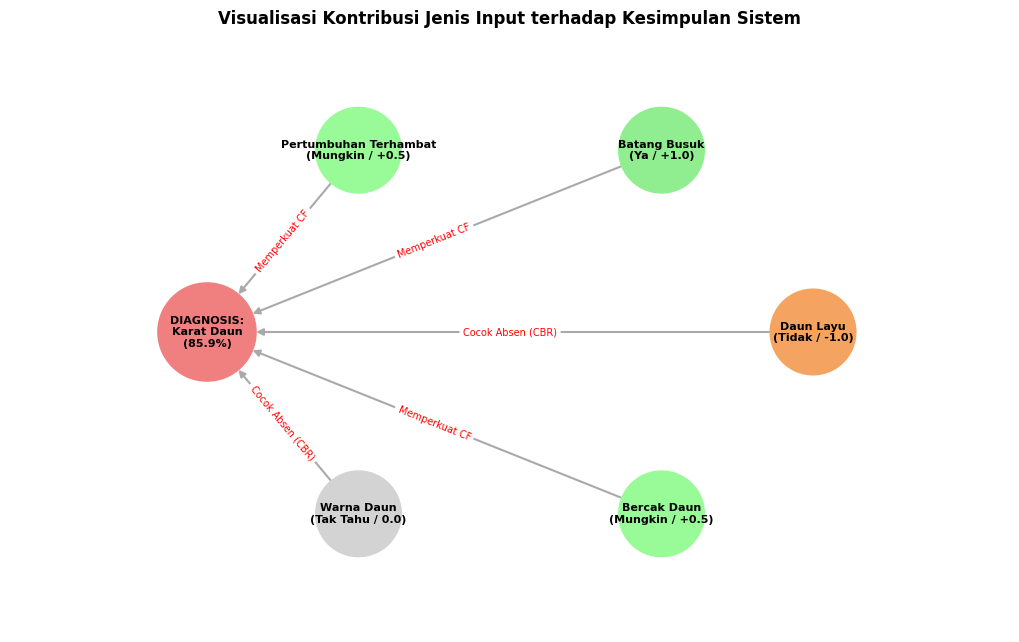


FASE EVALUASI & PEMBELAJARAN SISTEM (CBR REVISE)
Apakah hasil diagnosis dan solusi di atas BENAR? (y/n): n

[REVISE] Sistem mendeteksi kegagalan rekomendasi.
Silakan masukkan nama penyakit yg SEBENARNYA sesuai pengamatan Anda: Batang membusuk

[Info] Penyakit 'Batang Membusuk' adalah penyakit BARU yg belum ada di database.
Silakan ketik panduan/solusi penanganan untuk penyakit ini: Jangan menyiram tanaman melebihin takarannya

[Success Retain] Pengalaman kasus baru berhasil dipelajari dan disimpan ke knowledge_base.csv!
Total database kasus saat ini: 301 data.


In [ ]:
def main_program():
    global case_base

    print("=== SISTEM PAKAR HYBRID (CBR + CF) DIAGNOSIS PENYAKIT TANAMAN ===")

    if 'case_base' not in globals() or case_base.empty:
        print("Sistem dihentikan karena file dataset belum dimasukkan.")
        return

    options = {
        '1': ('Ya', 1.0),
        '2': ('Mungkin', 0.5),
        '3': ('Tidak Tahu', 0.0),
        '4': ('Mungkin Tidak', -0.5),
        '5': ('Tidak', -1.0)
    }

    def get_user_input(question):
        print(f"\n{question}")
        for key, val in options.items():
            print(f"{key}. {val[0]}")

        while True:
            choice = input("Pilih (1-5): ").strip()
            if choice in options:
                return options[choice]
            print("Input tidak valid. Silakan pilih 1-5.")

    print("Masukkan kondisi tanaman Anda saat ini:")
    nama_tanaman = input("- Apa nama tanaman? (misal: Mangga, Melon, dll): ").strip().title()

    gejala_list = [
        ('Warna_Daun', "- Apakah warna daun terlihat menguning?"),
        ('Bercak_Daun', "- Apakah ada bercak pada daun?"),
        ('Daun_Layu', "- Apakah daun terlihat layu?"),
        ('Batang_Busuk', "- Apakah batang membusuk?"),
        ('Pertumbuhan_Terhambat', "- Apakah pertumbuhan terhambat?")
    ]

    input_case = {'Nama_Tanaman': nama_tanaman}
    user_cf_values_asli = {}
    user_cf_values_hitung = {}

    for key, question in gejala_list:
        label, weight = get_user_input(question)

        # Seseorang dianggap merasakan gejala jika menjawab Ya atau Mungkin (weight > 0)
        input_case[key] = "Ya" if weight > 0 else "Tidak"

        # Simpan nilai mentah pilihan user (-1.0 s/d 1.0)
        user_cf_values_asli[key] = weight

        # Ambil hanya bobot positif untuk kalkulator CF
        user_cf_values_hitung[key] = weight if weight > 0 else 0

    print("\n--- TAHAP PENALARAN (HYBRID INFERENCE) ---")

    # Ambil hasil diagnosis menggunakan variabel filter 'hitung'
    diagnosis, cf_score, sim_score, best_case = compute_cf(input_case, user_cf_values_hitung)

    print(f"\nHasil Diagnosis: {diagnosis}")
    print(f"Similarity Score (CBR): {round(sim_score * 100, 2)}%")
    print(f"Certainty Factor: {round(cf_score * 100, 2)}%")

    if (sim_score + cf_score) > 0:
        final_hybrid = 2 * ((sim_score * cf_score) / (sim_score + cf_score))
    else:
        final_hybrid = 0.0

    print(f"Final Hybrid Confidence (Harmonic Mean): {round(final_hybrid * 100, 2)}%")

    # Tampilkan Solusi
    solusi = case_base[case_base['Penyakit'] == diagnosis]['Solusi'].values
    if len(solusi) > 0:
        print(f"\nSolusi: {solusi[0]}")

    explanation_facility(input_case, user_cf_values_asli, diagnosis, sim_score, cf_score, final_hybrid, best_case)

    # CBR REVISE
    print("\nFASE EVALUASI & PEMBELAJARAN SISTEM (CBR REVISE)")

    konfirmasi = input("Apakah hasil diagnosis dan solusi di atas BENAR? (y/n): ").strip().lower()

    if konfirmasi == 'y':
        if sim_score == 1.0:
            print("\n[Info] Kasus ini sudah 100% identik dengan pengetahuan di database.")
            print("Sistem tidak perlu menyimpan ulang untuk menghindari duplikasi data.")
        else:
            case_base = feedback_retain(input_case, diagnosis, case_base)

    elif konfirmasi == 'n':
        print("\n[REVISE] Sistem mendeteksi kegagalan rekomendasi.")
        penyakit_benar = input("Silakan masukkan nama penyakit yg SEBENARNYA sesuai pengamatan Anda: ").strip().title()

        # PENYAKIT 100% BARU
        if penyakit_benar not in case_base['Penyakit'].values:
            print(f"\n[Info] Penyakit '{penyakit_benar}' adalah penyakit BARU yg belum ada di database.")
            solusi_baru = input("Silakan ketik panduan/solusi penanganan untuk penyakit ini: ").strip()
            input_case['Solusi_Manual'] = solusi_baru

        case_base = feedback_retain(input_case, penyakit_benar, case_base)

    else:
        print("\n[Info] Evaluasi dilewati. Sistem tidak mempelajari kasus ini.")


main_program()